# Bukti Perhitungan Nilai Median dari Dataset Prosper Marketplace

**Tujuan:** Membuktikan bahwa nilai default yang digunakan dalam sistem prediksi kredit berasal dari **median** dataset training, bukan dari inisialisasi manual.

**Metode:** Median imputation — teknik standar di machine learning untuk mengisi fitur yang tidak tersedia. Median dipilih karena robust terhadap outlier, terutama pada data keuangan yang bersifat skewed (miring kanan).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")
sns.set_palette("husl")

print("Library berhasil di-import ✓")

Library berhasil di-import ✓


## 1. Load Dataset

In [6]:
df = pd.read_csv("C:/Users/ASUS TUF/Downloads/cleaning_prosperloandata.csv", low_memory=False)
print(f"Dataset       : CLEAN PROSPER LOAN")
print(f"Jumlah baris  : {len(df):,}")
print(f"Jumlah kolom  : {len(df.columns)}")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Dataset       : CLEAN PROSPER LOAN
Jumlah baris  : 113,937
Jumlah kolom  : 76
Memory usage  : 74.9 MB


### Nilai Spesifik ProsperScore dan ProsperRating

Berikut adalah nilai Mean dan Median untuk `ProsperScore` dan `ProsperRating (numeric)` secara langsung dari dataset Anda:

In [8]:
target_cols = ["ProsperScore", "ProsperRating (numeric)"]
for col in target_cols:
    if col in df.columns:
        series = pd.to_numeric(df[col], errors='coerce').dropna()
        print(f"=== {col} ===")
        print(f"Mean (Rata-rata) : {series.mean():.4f}")
        print(f"Median           : {series.median():.4f}")
        print()

=== ProsperScore ===
Mean (Rata-rata) : 5.9501
Median           : 5.9501

=== ProsperRating (numeric) ===
Mean (Rata-rata) : 4.0722
Median           : 4.0722



## 2. Kolom yang Digunakan untuk Median Imputation

Dari 26 fitur yang dibutuhkan model klasifikasi dan 41 fitur untuk model regresi, hanya **8 fitur yang diisi oleh user** melalui form frontend (Kredivo-style). Sisanya diisi menggunakan **median dari dataset training ini**.

In [9]:
# Kolom numerik yang median-nya digunakan sebagai default
kolom_numerik = [
    "CreditScoreRangeLower",
    "CreditScoreRangeUpper",
    "ProsperScore",
    "ProsperRating (numeric)",
    "BankcardUtilization",
    "AvailableBankcardCredit",
    "OpenRevolvingMonthlyPayment",
    "RevolvingCreditBalance",
    "OpenRevolvingAccounts",
    "CurrentCreditLines",
    "OpenCreditLines",
    "TotalCreditLinespast7years",
    "TotalTrades",
    "TradesNeverDelinquent (percentage)",
    "CurrentDelinquencies",
    "DelinquenciesLast7Years",
    "AmountDelinquent",
    "PublicRecordsLast10Years",
    "PublicRecordsLast12Months",
    "TotalInquiries",
    "InquiriesLast6Months",
    "TradesOpenedLast6Months",
    "EmploymentStatusDuration",
    "StatedMonthlyIncome",
    "DebtToIncomeRatio",
]

# Kolom kategorikal (menggunakan mode / nilai paling sering muncul)
kolom_kategorikal = [
    "ProsperRating (Alpha)",
    "EmploymentStatus",
    "IncomeRange",
    "Occupation",
    "BorrowerState",
    "IsBorrowerHomeowner",
]

print(f"Kolom numerik  : {len(kolom_numerik)}")
print(f"Kolom kategori : {len(kolom_kategorikal)}")
print(f"Total          : {len(kolom_numerik) + len(kolom_kategorikal)} kolom")

Kolom numerik  : 25
Kolom kategori : 6
Total          : 31 kolom


## 3. Perhitungan Median (Numerik)

Berikut adalah median dari setiap kolom numerik, beserta perbandingannya dengan mean dan skewness.

In [10]:
stats_list = []
for col in kolom_numerik:
    if col in df.columns:
        series = pd.to_numeric(df[col], errors='coerce').dropna()
        stats_list.append({
            "Kolom": col,
            "Count": int(series.count()),
            "MEDIAN": round(series.median(), 4),
            "Mean": round(series.mean(), 4),
            "Selisih": round(series.mean() - series.median(), 4),
            "Std Dev": round(series.std(), 4),
            "Min": round(series.min(), 4),
            "Max": round(series.max(), 4),
            "Skewness": round(series.skew(), 4),
        })
    else:
        print(f"  [WARNING] Kolom '{col}' tidak ditemukan di dataset!")

stats_df = pd.DataFrame(stats_list)
stats_df

,Kolom,Count,MEDIAN,Mean,Selisih,Std Dev,Min,Max,Skewness
0,CreditScoreRangeLower,113937,680.0000,685.5389,5.5389,66.2869,0.0000,880.0000,-1.5912
1,CreditScoreRangeUpper,113937,699.0000,704.5389,5.5389,66.2869,19.0000,899.0000,-1.5912
2,ProsperScore,113937,5.9501,5.9501,0.0000,2.0509,1.0000,11.0000,0.0422
3,ProsperRating (numeric),113937,4.0722,4.0722,0.0000,1.4440,1.0000,7.0000,-0.1585
4,BankcardUtilization,113937,0.5612,0.5612,0.0000,0.3061,0.0000,2.4300,-0.2557
5,AvailableBankcardCredit,113937,"4,100.0000","9,549.5902","5,449.5902","12,926.9573",0.0000,"50,080.0000",1.8671
6,OpenRevolvingMonthlyPayment,113937,271.0000,386.7658,115.7658,383.6743,0.0000,"1,758.0000",1.6674
7,RevolvingCreditBalance,113937,"8,549.0000","14,517.7768","5,968.7768","16,846.3640",0.0000,"68,721.0000",1.8668
8,OpenRevolvingAccounts,113937,6.0000,6.9698,0.9698,4.6310,0.0000,51.0000,1.3129
9,CurrentCreditLines,113937,10.0000,10.2960,0.2960,5.2732,0.0000,59.0000,1.0725


## 4. Perhitungan Mode (Kategorikal)

In [11]:
mode_list = []
for col in kolom_kategorikal:
    if col in df.columns:
        series = df[col].dropna()
        mode_val = series.mode().iloc[0] if len(series.mode()) > 0 else "N/A"
        mode_count = (series == mode_val).sum()
        mode_pct = mode_count / len(series) * 100
        mode_list.append({
            "Kolom": col,
            "Count": int(series.count()),
            "MODE (Nilai Default)": mode_val,
            "Frekuensi Mode": int(mode_count),
            "Persentase": f"{mode_pct:.1f}%",
        })

mode_df = pd.DataFrame(mode_list)
mode_df

,Kolom,Count,MODE (Nilai Default),Frekuensi Mode,Persentase
0,Occupation,113937,35,28617,25.1%
1,BorrowerState,113937,4,14717,12.9%
2,IsBorrowerHomeowner,113937,1,57478,50.4%


## 5. Mengapa Median, Bukan Mean?

Distribusi data keuangan bersifat **skewed (miring kanan)** — artinya ada segelintir nilai ekstrem (outlier) yang menarik mean ke atas. Median lebih **robust** terhadap outlier dan lebih merepresentasikan **nasabah tipikal**.

Visualisasi berikut membuktikan bahwa sebagian besar kolom bersifat skewed:

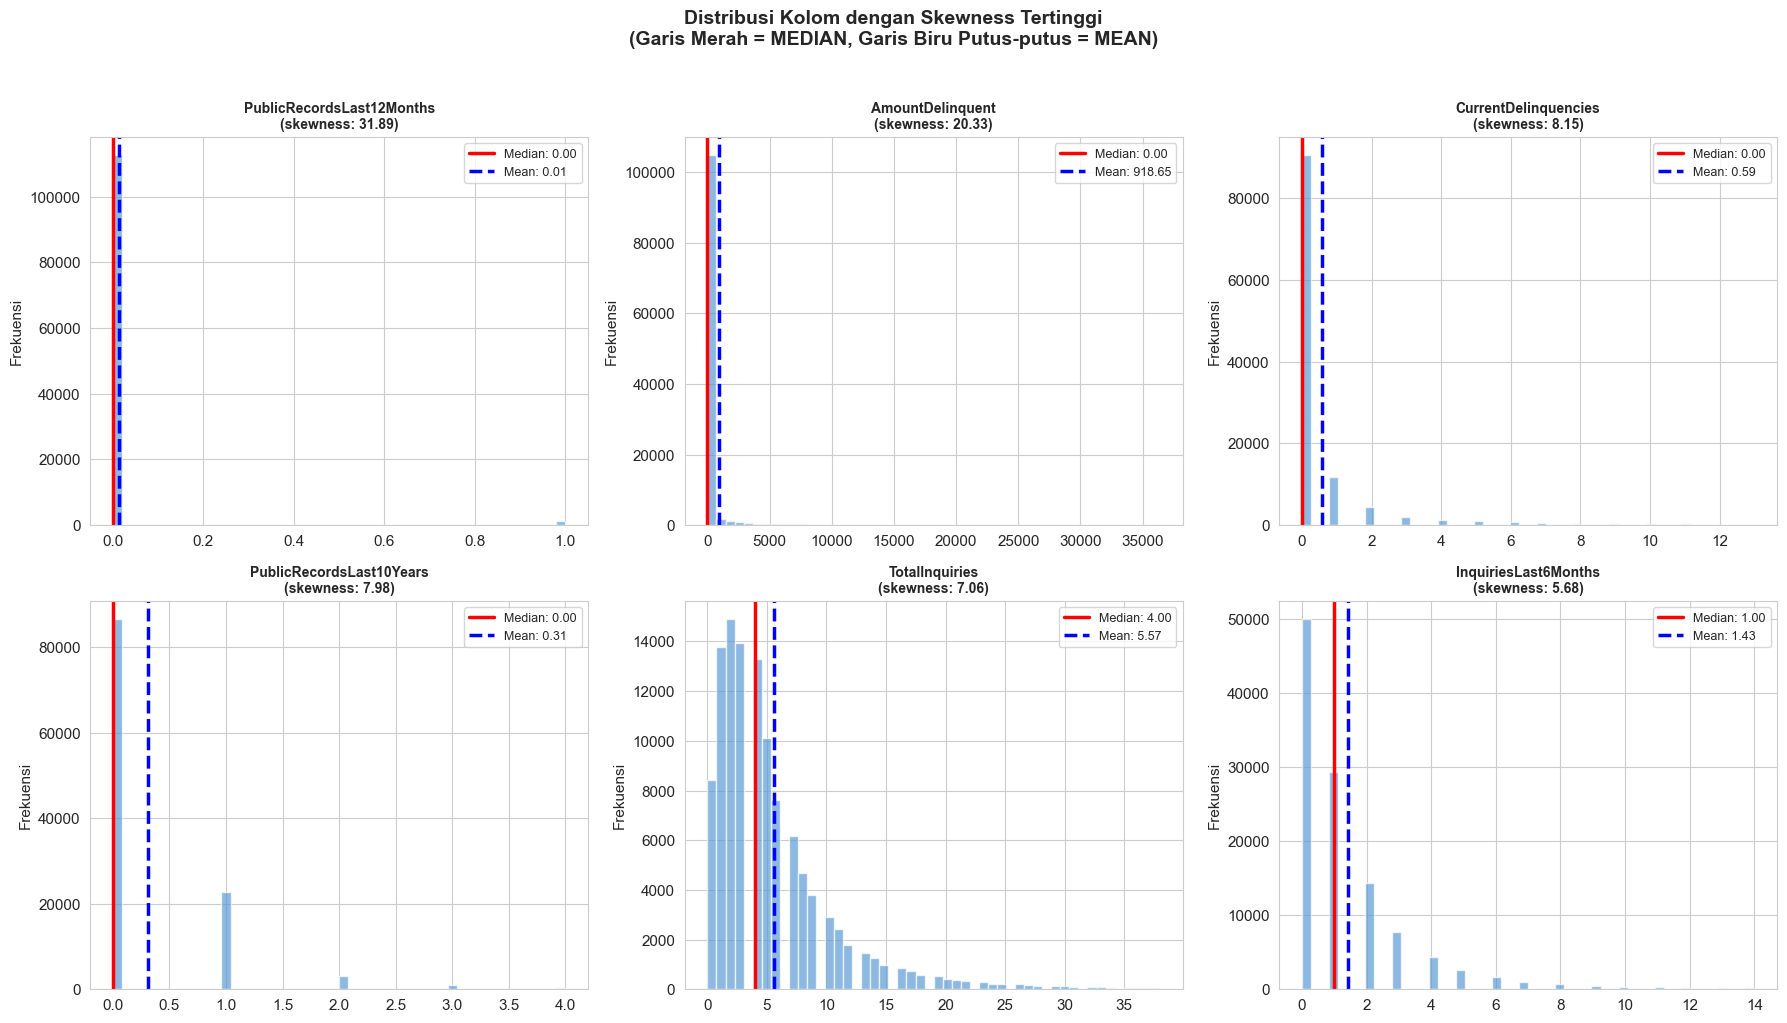


✓ Grafik disimpan: bukti_median_vs_mean_distribusi.png


In [12]:
# Visualisasi distribusi: 6 kolom dengan skewness tertinggi
skewed_cols = stats_df.nlargest(6, "Skewness")["Kolom"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    "Distribusi Kolom dengan Skewness Tertinggi\n"
    "(Garis Merah = MEDIAN, Garis Biru Putus-putus = MEAN)",
    fontsize=14, fontweight='bold', y=1.02
)

for idx, col in enumerate(skewed_cols):
    ax = axes[idx // 3][idx % 3]
    series = pd.to_numeric(df[col], errors='coerce').dropna()

    # Clip outlier ekstrem untuk visualisasi yang lebih jelas
    upper = series.quantile(0.995)
    series_clipped = series[series <= upper]

    ax.hist(series_clipped, bins=50, color='#5B9BD5', alpha=0.7, edgecolor='white')

    median_val = series.median()
    mean_val = series.mean()

    ax.axvline(median_val, color='red', linewidth=2.5, label=f'Median: {median_val:,.2f}')
    ax.axvline(mean_val, color='blue', linewidth=2.5, linestyle='--', label=f'Mean: {mean_val:,.2f}')

    skew_val = series.skew()
    ax.set_title(f"{col}\n(skewness: {skew_val:.2f})", fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylabel("Frekuensi")

plt.tight_layout()
plt.savefig("bukti_median_vs_mean_distribusi.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Grafik disimpan: bukti_median_vs_mean_distribusi.png")

## 7. Validasi Delinquency: Median = 0 adalah Benar

Pertanyaan penting: mengapa median `CurrentDelinquencies` = 0? Karena **mayoritas nasabah memang tidak memiliki tunggakan.**

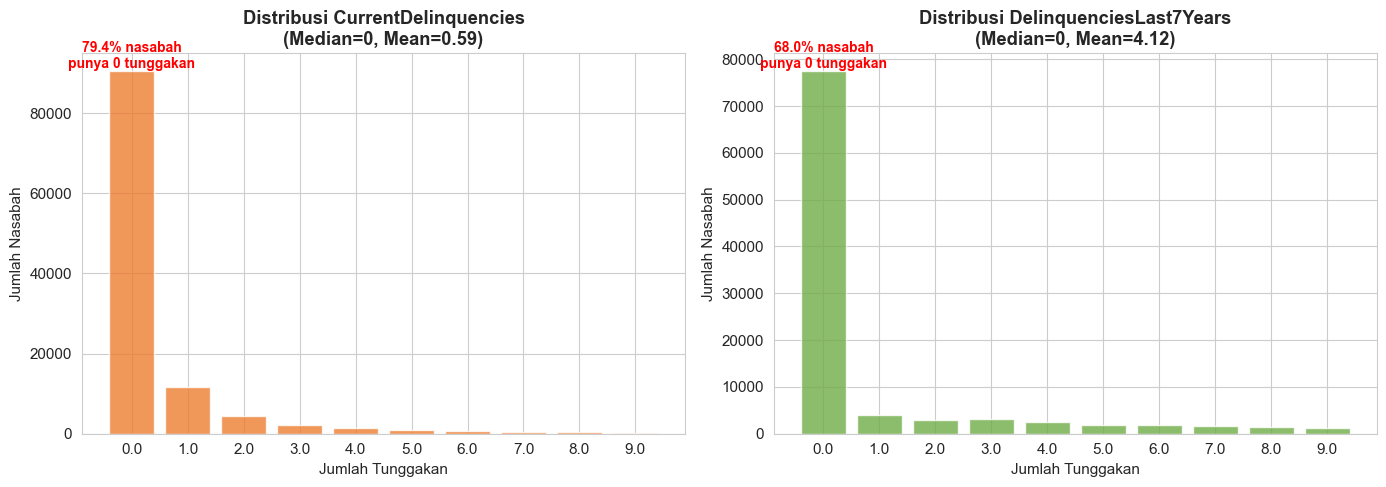


✓ Grafik disimpan: bukti_median_delinquency.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color in zip(axes, 
    ["CurrentDelinquencies", "DelinquenciesLast7Years"],
    ['#ED7D31', '#70AD47']
):
    series = pd.to_numeric(df[col], errors='coerce').dropna()
    val_counts = series.value_counts().sort_index().head(10)

    ax.bar(val_counts.index.astype(str), val_counts.values, color=color, alpha=0.8)
    ax.set_title(
        f"Distribusi {col}\n(Median={series.median():.0f}, Mean={series.mean():.2f})",
        fontweight='bold'
    )
    ax.set_xlabel("Jumlah Tunggakan")
    ax.set_ylabel("Jumlah Nasabah")

    pct_zero = (series == 0).sum() / len(series) * 100
    ax.annotate(
        f'{pct_zero:.1f}% nasabah\npunya 0 tunggakan',
        xy=(0, val_counts.iloc[0]), fontsize=10, fontweight='bold',
        ha='center', va='bottom', color='red'
    )

plt.tight_layout()
plt.savefig("bukti_median_delinquency.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Grafik disimpan: bukti_median_delinquency.png")

## 8. Tabel Final: Nilai Default yang Digunakan di Sistem Prediksi

In [15]:
print("=" * 70)
print("  NILAI DEFAULT FINAL (DIGUNAKAN DI backend/predictor.py)")
print("=" * 70)

print("\n  === NUMERIK (MEDIAN dari dataset) ===")
print(f"  {'Kolom':<45} {'Nilai Default':>15}")
print("  " + "-" * 62)
for _, row in stats_df.iterrows():
    val = row['MEDIAN']
    if val == int(val):
        print(f"  {row['Kolom']:<45} {int(val):>15,}")
    else:
        print(f"  {row['Kolom']:<45} {val:>15,.4f}")

print(f"\n  === KATEGORIKAL (MODE dari dataset) ===")
print(f"  {'Kolom':<45} {'Nilai Default':>15}")
print("  " + "-" * 62)
for _, row in mode_df.iterrows():
    print(f"  {row['Kolom']:<45} {str(row['MODE (Nilai Default)']):>15}")

  NILAI DEFAULT FINAL (DIGUNAKAN DI backend/predictor.py)

  === NUMERIK (MEDIAN dari dataset) ===
  Kolom                                           Nilai Default
  --------------------------------------------------------------
  CreditScoreRangeLower                                     680
  CreditScoreRangeUpper                                     699
  ProsperScore                                           5.9501
  ProsperRating (numeric)                                4.0722
  BankcardUtilization                                    0.5612
  AvailableBankcardCredit                                 4,100
  OpenRevolvingMonthlyPayment                               271
  RevolvingCreditBalance                                  8,549
  OpenRevolvingAccounts                                       6
  CurrentCreditLines                                         10
  OpenCreditLines                                             9
  TotalCreditLinespast7years                                 25
  To